# Wine Quality Model Comparison

This notebook compares several models on `winequalityN.csv`.

It uses two related targets:
- Regression target: `quality`
- Classification target for the logit comparison: `good_quality = 1` when `quality >= 7`, else `0`

Lasso is used to identify relevant variables, and that selected feature set is then reused across the downstream models.

In [1]:
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV, LinearRegression, LogisticRegression, RidgeCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from imblearn.over_sampling import SMOTE
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn"])
    from imblearn.over_sampling import SMOTE

try:
    from xgboost import XGBClassifier, XGBRegressor
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
    from xgboost import XGBClassifier, XGBRegressor

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
RANDOM_STATE = 42

## Load And Describe The Data

We start by loading the wine dataset, checking its structure, and creating a readable variable summary.

In [2]:
data_path = Path.cwd() / "winequalityN.csv"
if not data_path.exists():
    raise FileNotFoundError(f"Could not find dataset at {data_path}")

wine = pd.read_csv(data_path)
wine.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [3]:
variable_descriptions = {
    "type": "Wine type: red or white.",
    "fixed acidity": "Non-volatile acids that contribute to tartness.",
    "volatile acidity": "Volatile acids; higher values can lead to vinegar-like notes.",
    "citric acid": "Adds freshness and structure.",
    "residual sugar": "Sugar remaining after fermentation.",
    "chlorides": "Salt content in the wine.",
    "free sulfur dioxide": "Free SO2 available to protect the wine.",
    "total sulfur dioxide": "Total SO2 concentration.",
    "density": "Density of the wine sample.",
    "pH": "Acidity/basicity measure.",
    "sulphates": "Wine additive that can contribute to preservation.",
    "alcohol": "Alcohol percentage.",
    "quality": "Quality score assigned to the wine."
}

variable_summary = pd.DataFrame(
    {
        "Variable": wine.columns,
        "Type": [str(wine[col].dtype) for col in wine.columns],
        "Missing Values": [int(wine[col].isna().sum()) for col in wine.columns],
        "Unique Values": [int(wine[col].nunique(dropna=True)) for col in wine.columns],
        "Description": [variable_descriptions.get(col, "") for col in wine.columns],
    }
)

display(pd.DataFrame({"Rows": [wine.shape[0]], "Columns": [wine.shape[1]]}))
display(variable_summary)

,Rows,Columns
0,6497,13


,Variable,Type,Missing Values,Unique Values,Description
0,type,object,0,2,Wine type: red or white.
1,fixed acidity,float64,10,106,Non-volatile acids that contribute to tartness.
2,volatile acidity,float64,8,187,Volatile acids; higher values can lead to vine...
3,citric acid,float64,3,89,Adds freshness and structure.
4,residual sugar,float64,2,316,Sugar remaining after fermentation.
5,chlorides,float64,2,214,Salt content in the wine.
6,free sulfur dioxide,float64,0,135,Free SO2 available to protect the wine.
7,total sulfur dioxide,float64,0,276,Total SO2 concentration.
8,density,float64,0,998,Density of the wine sample.
9,pH,float64,9,108,Acidity/basicity measure.


## Variable Plots

These plots summarize the target distribution, wine types, missing values, and the main numeric relationships.

/var/folders/gz/cs5w2f4s18l86vs9_v21ym1r0000gn/T/ipykernel_44176/1421371838.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=wine, x="type", ax=axes[1], palette="Set2")


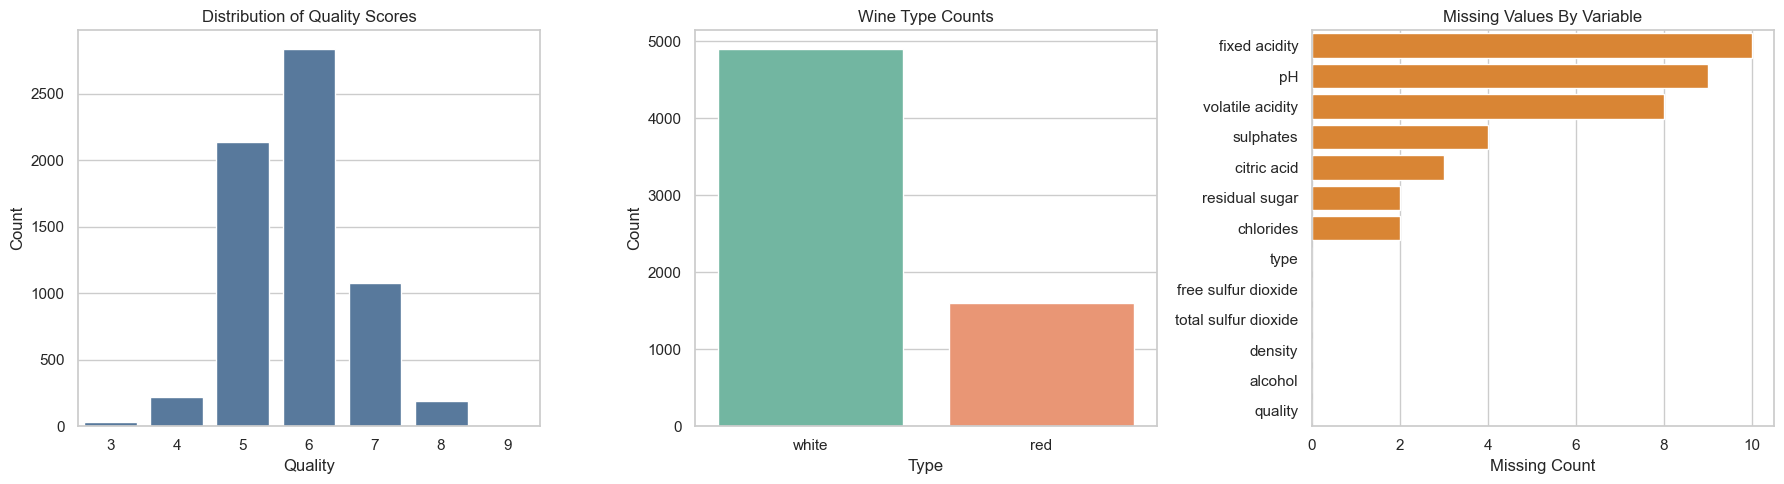

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=wine, x="quality", ax=axes[0], color="#4C78A8")
axes[0].set_title("Distribution of Quality Scores")
axes[0].set_xlabel("Quality")
axes[0].set_ylabel("Count")

sns.countplot(data=wine, x="type", ax=axes[1], palette="Set2")
axes[1].set_title("Wine Type Counts")
axes[1].set_xlabel("Type")
axes[1].set_ylabel("Count")

missing_counts = wine.isna().sum().sort_values(ascending=False)
sns.barplot(x=missing_counts.values, y=missing_counts.index, ax=axes[2], color="#F58518")
axes[2].set_title("Missing Values By Variable")
axes[2].set_xlabel("Missing Count")
axes[2].set_ylabel("")

plt.tight_layout()

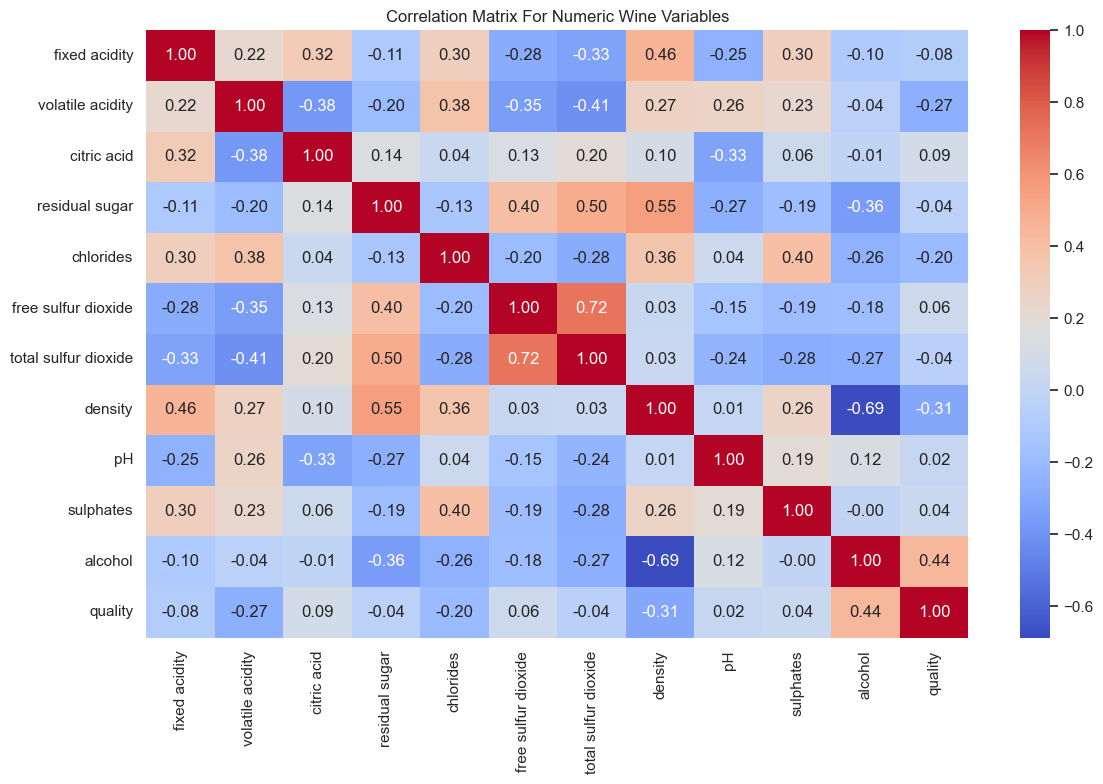

In [5]:
numeric_wine = wine.select_dtypes(include=np.number)

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_wine.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix For Numeric Wine Variables")
plt.tight_layout()

## Prepare Targets And Features

We create a binary target for the logit model, split the data once so every model is evaluated on the same observations, and preprocess the features for the linear models.

In [6]:
wine_model = wine.copy()
wine_model["good_quality"] = (wine_model["quality"] >= 7).astype(int)

X = wine_model.drop(columns=["quality", "good_quality"])
y_reg = wine_model["quality"]
y_clf = wine_model["good_quality"]

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X,
    y_reg,
    y_clf,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_clf,
)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ]
)

X_train_linear = linear_preprocessor.fit_transform(X_train)
X_test_linear = linear_preprocessor.transform(X_test)
X_train_tree = tree_preprocessor.fit_transform(X_train)
X_test_tree = tree_preprocessor.transform(X_test)

feature_names = linear_preprocessor.get_feature_names_out().tolist()
feature_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

display(pd.DataFrame({"Candidate Variables": feature_names}))

,Candidate Variables
0,fixed acidity
1,volatile acidity
2,citric acid
3,residual sugar
4,chlorides
5,free sulfur dioxide
6,total sulfur dioxide
7,density
8,pH
9,sulphates


## Lasso Variable Selection

Lasso regression is fit on the training set only. Its non-zero coefficients are treated as the relevant variables, and that reduced feature set is used by the later models.

In [7]:
lasso_selector = LassoCV(cv=5, random_state=RANDOM_STATE)
lasso_selector.fit(X_train_linear, y_reg_train)

lasso_coefficients = pd.DataFrame(
    {
        "Variable": feature_names,
        "Lasso Coefficient": lasso_selector.coef_,
    }
)
lasso_coefficients["Selected"] = lasso_coefficients["Lasso Coefficient"].abs() > 1e-8
lasso_coefficients = lasso_coefficients.assign(
    Absolute_Coefficient=lasso_coefficients["Lasso Coefficient"].abs()
).sort_values(["Selected", "Absolute_Coefficient"], ascending=[False, False])

selected_features = lasso_coefficients.loc[lasso_coefficients["Selected"], "Variable"].tolist()
if not selected_features:
    selected_features = feature_names.copy()
    lasso_coefficients["Selected"] = True

selected_mask = np.array([feature in selected_features for feature in feature_names])
X_train_selected_linear = X_train_linear[:, selected_mask]
X_test_selected_linear = X_test_linear[:, selected_mask]
X_train_selected_tree = X_train_tree[:, selected_mask]
X_test_selected_tree = X_test_tree[:, selected_mask]

display(pd.DataFrame({"Selected Variables": selected_features}))
display(lasso_coefficients[["Variable", "Lasso Coefficient", "Selected"]].round(4))

,Selected Variables
0,type_white
1,alcohol
2,residual sugar
3,density
4,volatile acidity
5,sulphates
6,fixed acidity
7,total sulfur dioxide
8,free sulfur dioxide
9,pH


,Variable,Lasso Coefficient,Selected
11,type_white,-0.3345,True
10,alcohol,0.2831,True
3,residual sugar,0.2711,True
7,density,-0.2609,True
1,volatile acidity,-0.2488,True
9,sulphates,0.1157,True
0,fixed acidity,0.0817,True
6,total sulfur dioxide,-0.0763,True
5,free sulfur dioxide,0.0748,True
8,pH,0.0652,True


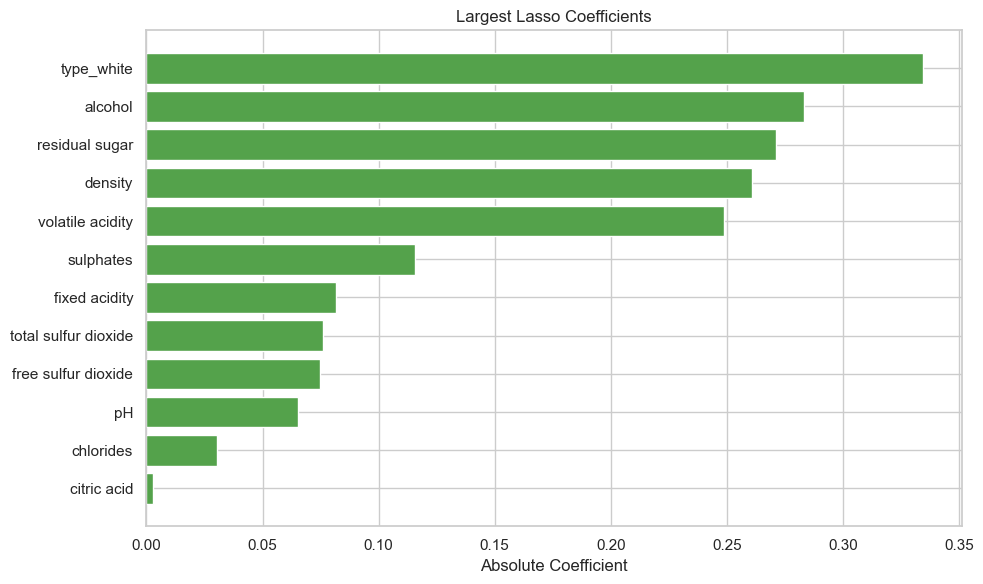

In [8]:
plt.figure(figsize=(10, 6))
coef_plot = lasso_coefficients.head(12).sort_values("Absolute_Coefficient")
colors = np.where(coef_plot["Selected"], "#54A24B", "#E45756")
plt.barh(coef_plot["Variable"], coef_plot["Absolute_Coefficient"], color=colors)
plt.title("Largest Lasso Coefficients")
plt.xlabel("Absolute Coefficient")
plt.ylabel("")
plt.tight_layout()

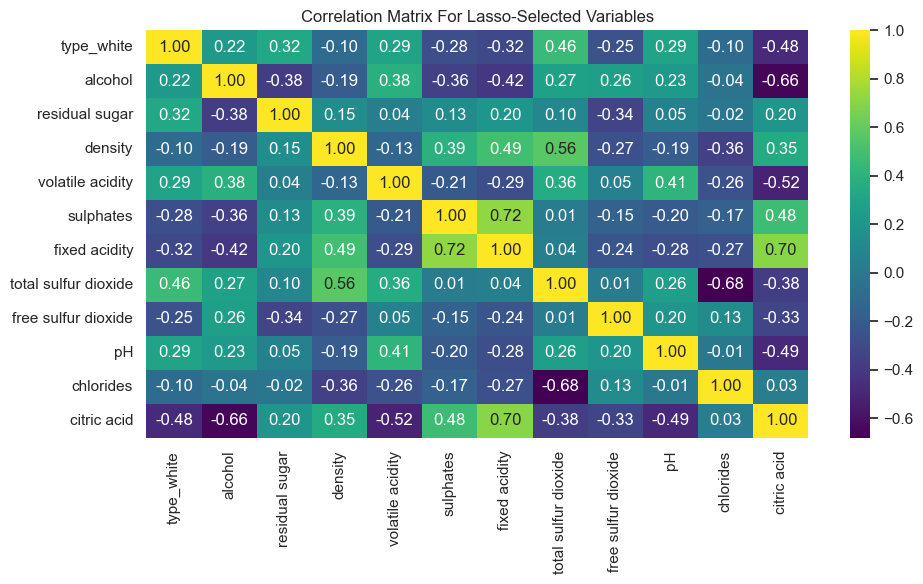

In [9]:
selected_correlation = pd.DataFrame(X_train_selected_linear, columns=selected_features)

plt.figure(figsize=(10, 6))
sns.heatmap(selected_correlation.corr(), annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation Matrix For Lasso-Selected Variables")
plt.tight_layout()

## Regression Model Comparison

All regression models below predict the original `quality` score and use the variables selected by Lasso.

In [10]:
regression_models = {
    "Linear Regression": LinearRegression(),
    "Lasso": LassoCV(cv=5, random_state=RANDOM_STATE),
    "Ridge": RidgeCV(alphas=np.logspace(-3, 3, 25)),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, max_depth=8),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        objective="reg:squarederror",
    ),
}

regression_rows = []
regression_predictions = {}

for model_name, model in regression_models.items():
    if model_name in {"Random Forest", "XGBoost"}:
        model.fit(X_train_selected_tree, y_reg_train)
        preds = model.predict(X_test_selected_tree)
    else:
        model.fit(X_train_selected_linear, y_reg_train)
        preds = model.predict(X_test_selected_linear)

    regression_predictions[model_name] = preds
    regression_rows.append(
        {
            "Model": model_name,
            "RMSE": mean_squared_error(y_reg_test, preds, squared=False),
            "MAE": mean_absolute_error(y_reg_test, preds),
            "R2": r2_score(y_reg_test, preds),
        }
    )

regression_results = pd.DataFrame(regression_rows).sort_values("RMSE")
display(regression_results.round(3))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use 

,Model,RMSE,MAE,R2
4,XGBoost,0.672,0.519,0.416
3,Random Forest,0.681,0.530,0.399
0,Linear Regression,0.738,0.575,0.295
1,Lasso,0.738,0.575,0.294
2,Ridge,0.738,0.575,0.294


/var/folders/gz/cs5w2f4s18l86vs9_v21ym1r0000gn/T/ipykernel_44176/1075148245.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regression_results, x="RMSE", y="Model", ax=axes[0], palette="Blues_r")
/var/folders/gz/cs5w2f4s18l86vs9_v21ym1r0000gn/T/ipykernel_44176/1075148245.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regression_results.sort_values("R2", ascending=False), x="R2", y="Model", ax=axes[1], palette="Greens")


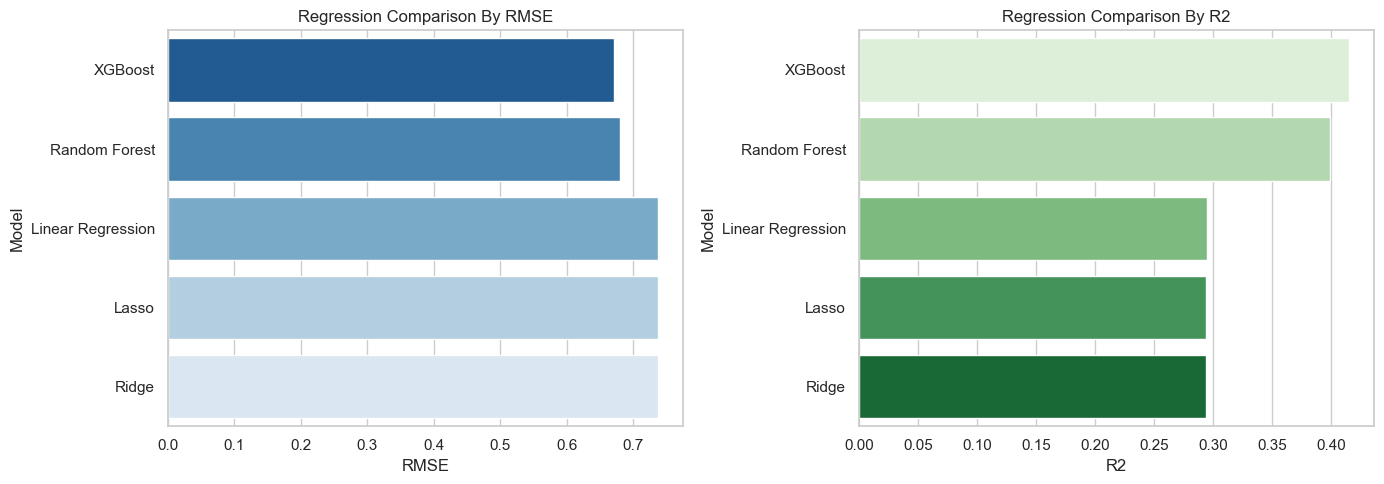

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=regression_results, x="RMSE", y="Model", ax=axes[0], palette="Blues_r")
axes[0].set_title("Regression Comparison By RMSE")

sns.barplot(data=regression_results.sort_values("R2", ascending=False), x="R2", y="Model", ax=axes[1], palette="Greens")
axes[1].set_title("Regression Comparison By R2")

plt.tight_layout()

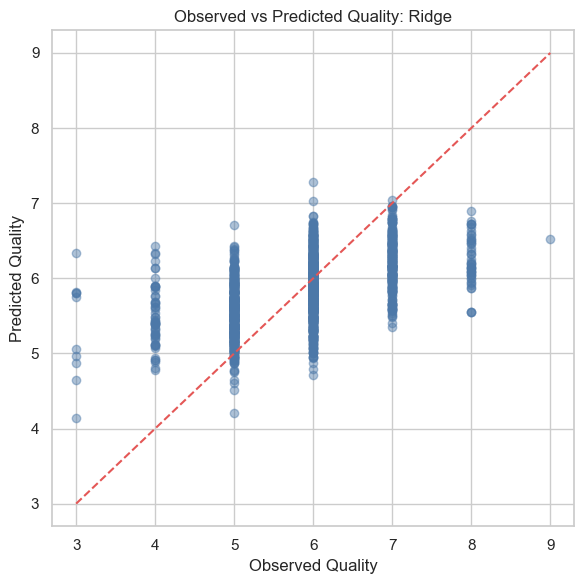

In [12]:
best_regression_model = regression_results.iloc[-1]["Model"]

plt.figure(figsize=(6, 6))
plt.scatter(y_reg_test, regression_predictions[best_regression_model], alpha=0.45, color="#4C78A8")
plt.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], color="#E45756", linestyle="--")
plt.title(f"Observed vs Predicted Quality: {best_regression_model}")
plt.xlabel("Observed Quality")
plt.ylabel("Predicted Quality")
plt.tight_layout()

## Classification Model Comparison

For the logit comparison, we predict whether a wine is high quality (`quality >= 7`). The same Lasso-selected variables are reused here, and the models are fit on the original train-test split without rebalancing.

In [13]:
classification_train_distribution = y_clf_train.value_counts().sort_index().rename_axis("Class").reset_index(name="Count")
display(classification_train_distribution)

,Class,Count
0,0,3914
1,1,958


In [14]:
classification_models = {
    "Logit": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, max_depth=8),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
    ),
}

classification_rows = []
classification_predictions = {}

for model_name, model in classification_models.items():
    if model_name in {"Random Forest", "XGBoost"}:
        model.fit(X_train_selected_tree, y_clf_train)
        preds = model.predict(X_test_selected_tree)
        probs = model.predict_proba(X_test_selected_tree)[:, 1]
    else:
        model.fit(X_train_selected_linear, y_clf_train)
        preds = model.predict(X_test_selected_linear)
        probs = model.predict_proba(X_test_selected_linear)[:, 1]

    classification_predictions[model_name] = preds
    classification_rows.append(
        {
            "Model": model_name,
            "Accuracy": accuracy_score(y_clf_test, preds),
            "Precision": precision_score(y_clf_test, preds),
            "Recall": recall_score(y_clf_test, preds),
            "F1": f1_score(y_clf_test, preds),
            "ROC AUC": roc_auc_score(y_clf_test, probs),
        }
    )

classification_results = pd.DataFrame(classification_rows).sort_values("ROC AUC", ascending=False)
display(classification_results.round(3))

,Model,Accuracy,Precision,Recall,F1,ROC AUC
2,XGBoost,0.853,0.690,0.455,0.548,0.889
1,Random Forest,0.859,0.781,0.392,0.522,0.880
0,Logit,0.814,0.553,0.260,0.354,0.810


/var/folders/gz/cs5w2f4s18l86vs9_v21ym1r0000gn/T/ipykernel_44176/2529985480.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=classification_results, x="Accuracy", y="Model", ax=axes[0], palette="Oranges")
/var/folders/gz/cs5w2f4s18l86vs9_v21ym1r0000gn/T/ipykernel_44176/2529985480.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=classification_results.sort_values("ROC AUC", ascending=False), x="ROC AUC", y="Model", ax=axes[1], palette="Purples")


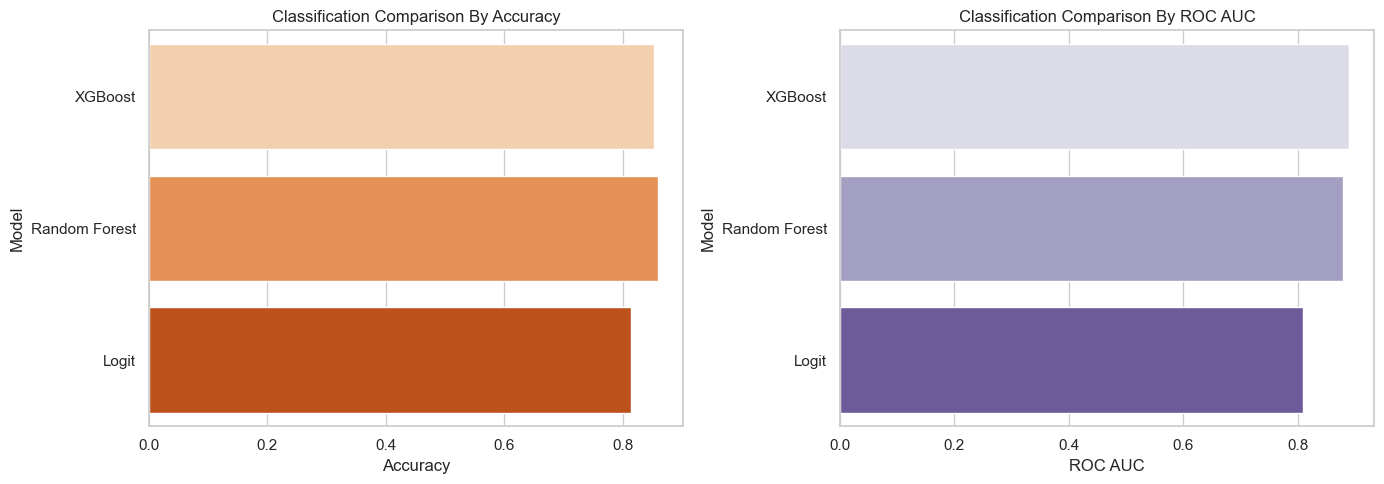

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=classification_results, x="Accuracy", y="Model", ax=axes[0], palette="Oranges")
axes[0].set_title("Classification Comparison By Accuracy")

sns.barplot(data=classification_results.sort_values("ROC AUC", ascending=False), x="ROC AUC", y="Model", ax=axes[1], palette="Purples")
axes[1].set_title("Classification Comparison By ROC AUC")

plt.tight_layout()

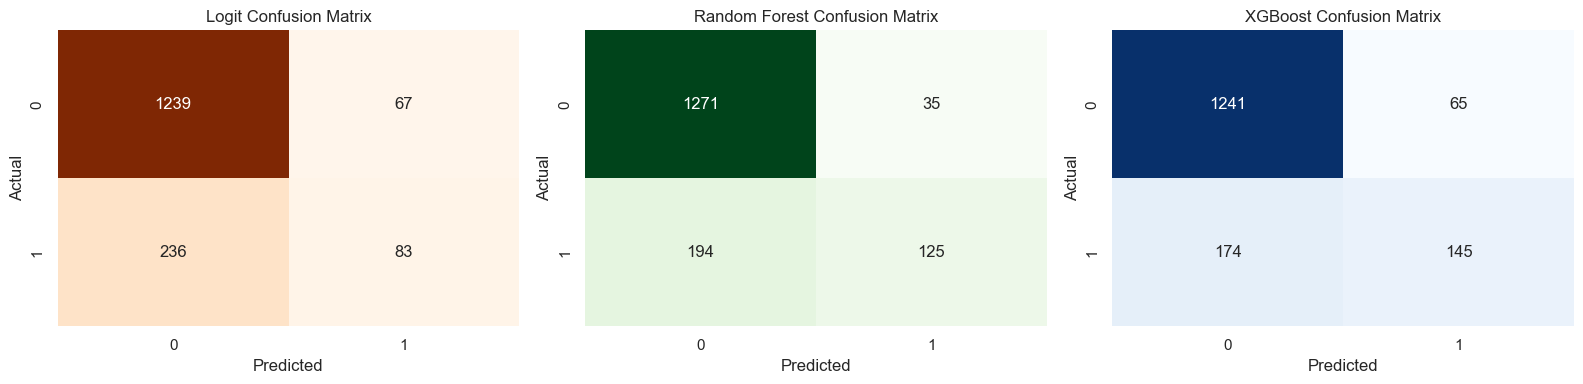

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (model_name, preds), cmap in zip(
    axes,
    classification_predictions.items(),
    ["Oranges", "Greens", "Blues"],
):
    sns.heatmap(confusion_matrix(y_clf_test, preds), annot=True, fmt="d", cbar=False, cmap=cmap, ax=ax)
    ax.set_title(f"{model_name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()

## Summary

The comparison tables and plots above show how the linear, regularized, tree-based, and boosting models perform on the wine data using the same Lasso-selected variables. The selected-variable table is especially useful for explaining which chemistry variables appear most relevant before fitting the larger model set.

## SMOTE For Quality 8 And 9

This final section creates synthetic training observations for wines with quality grades `8` and `9` using SMOTE. The test set is left unchanged. We then retrain the model family and report both performance and the top variables for each model.

In [17]:
quality_train_distribution = y_reg_train.value_counts().sort_index().rename_axis("Quality").reset_index(name="Count")

smote_target_count = int(y_reg_train.value_counts().loc[7])
smote_strategy = {8: smote_target_count, 9: smote_target_count}

smote = SMOTE(sampling_strategy=smote_strategy, random_state=RANDOM_STATE, k_neighbors=2)
X_train_smote_linear, y_train_smote = smote.fit_resample(X_train_selected_linear, y_reg_train)
X_train_smote_tree, _ = smote.fit_resample(X_train_selected_tree, y_reg_train)

quality_train_distribution_smote = pd.Series(y_train_smote).value_counts().sort_index().rename_axis("Quality").reset_index(name="Count")
quality_balance_summary = quality_train_distribution.merge(
    quality_train_distribution_smote,
    on="Quality",
    how="outer",
    suffixes=(" Before SMOTE", " After SMOTE"),
).fillna(0)
display(quality_balance_summary)

,Quality,Count Before SMOTE,Count After SMOTE
0,3,20,20
1,4,159,159
2,5,1608,1608
3,6,2127,2127
4,7,807,807
5,8,147,807
6,9,4,807


In [18]:
quality_levels = sorted(pd.Series(y_train_smote).unique().tolist())
quality_to_code = {quality: index for index, quality in enumerate(quality_levels)}
code_to_quality = {index: quality for quality, index in quality_to_code.items()}

y_train_smote_code = np.array([quality_to_code[value] for value in y_train_smote])

In [19]:
smote_models = {
    "Linear Regression": LinearRegression(),
    "Logit": LogisticRegression(max_iter=2000, multi_class="multinomial", random_state=RANDOM_STATE),
    "Lasso": LogisticRegression(
        penalty="l1",
        solver="saga",
        max_iter=4000,
        multi_class="multinomial",
        random_state=RANDOM_STATE,
    ),
    "Ridge": LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=4000,
        multi_class="multinomial",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
    ),
}

smote_performance_rows = []
smote_top_variable_rows = []

for model_name, model in smote_models.items():
    if model_name == "Linear Regression":
        model.fit(X_train_smote_linear, y_train_smote)
        raw_predictions = model.predict(X_test_selected_linear)
        allowed_levels = np.array(quality_levels)
        preds = np.clip(np.rint(raw_predictions), allowed_levels.min(), allowed_levels.max()).astype(int)
        importance = np.abs(model.coef_)
    elif model_name in {"Logit", "Lasso", "Ridge"}:
        model.fit(X_train_smote_linear, y_train_smote)
        preds = model.predict(X_test_selected_linear)
        importance = np.abs(model.coef_).mean(axis=0)
    elif model_name == "Random Forest":
        model.fit(X_train_smote_tree, y_train_smote)
        preds = model.predict(X_test_selected_tree)
        importance = model.feature_importances_
    else:
        model.fit(X_train_smote_tree, y_train_smote_code)
        pred_codes = model.predict(X_test_selected_tree).astype(int)
        preds = np.array([code_to_quality[int(code)] for code in pred_codes])
        importance = model.feature_importances_

    smote_performance_rows.append(
        {
            "Model": model_name,
            "Accuracy": accuracy_score(y_reg_test, preds),
            "Balanced Accuracy": balanced_accuracy_score(y_reg_test, preds),
            "Macro F1": f1_score(y_reg_test, preds, average="macro"),
        }
    )

    top_variables = pd.DataFrame(
        {
            "Variable": selected_features,
            "Importance": importance,
        }
    ).sort_values("Importance", ascending=False).head(5)

    for _, row in top_variables.iterrows():
        smote_top_variable_rows.append(
            {
                "Model": model_name,
                "Variable": row["Variable"],
                "Importance": row["Importance"],
            }
        )

smote_results = pd.DataFrame(smote_performance_rows).sort_values("Balanced Accuracy", ascending=False)
smote_top_variables = pd.DataFrame(smote_top_variable_rows)

display(smote_results.round(3))
display(smote_top_variables.round(4))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,Model,Accuracy,Balanced Accuracy,Macro F1
2,Lasso,0.484,0.371,0.215
1,Logit,0.484,0.371,0.212
3,Ridge,0.484,0.371,0.212
5,XGBoost,0.579,0.289,0.285
4,Random Forest,0.581,0.275,0.265
0,Linear Regression,0.436,0.245,0.232


,Model,Variable,Importance
0,Linear Regression,total sulfur dioxide,1.1166
1,Linear Regression,density,0.8349
2,Linear Regression,type_white,0.6398
3,Linear Regression,citric acid,0.4693
4,Linear Regression,free sulfur dioxide,0.4653
5,Logit,volatile acidity,2.1452
6,Logit,type_white,1.8207
7,Logit,citric acid,1.4806
8,Logit,total sulfur dioxide,1.2775
9,Logit,free sulfur dioxide,1.0737


/var/folders/gz/cs5w2f4s18l86vs9_v21ym1r0000gn/T/ipykernel_44176/4190824512.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=smote_results, x="Balanced Accuracy", y="Model", ax=axes[0], palette="crest")
/var/folders/gz/cs5w2f4s18l86vs9_v21ym1r0000gn/T/ipykernel_44176/4190824512.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=smote_results.sort_values("Macro F1", ascending=False), x="Macro F1", y="Model", ax=axes[1], palette="flare")


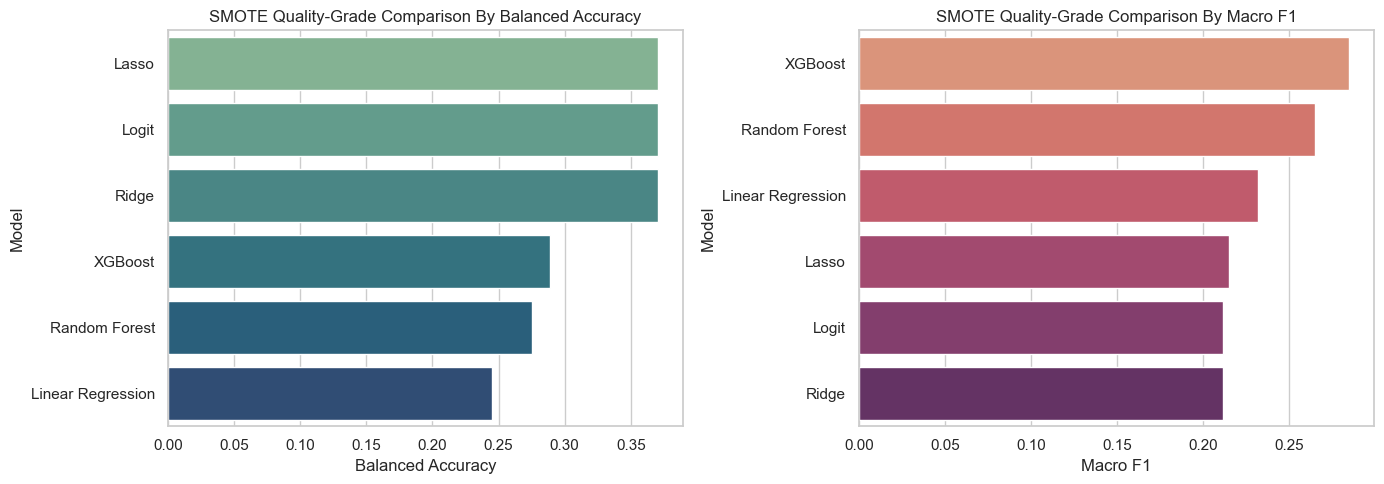

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=smote_results, x="Balanced Accuracy", y="Model", ax=axes[0], palette="crest")
axes[0].set_title("SMOTE Quality-Grade Comparison By Balanced Accuracy")

sns.barplot(data=smote_results.sort_values("Macro F1", ascending=False), x="Macro F1", y="Model", ax=axes[1], palette="flare")
axes[1].set_title("SMOTE Quality-Grade Comparison By Macro F1")

plt.tight_layout()